In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B.Spot 9052.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Spot 8972.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/e4e7e5a2-5aa1-4378-833d-9142358c7c9b___JR_B.Spot 9092.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/8b50f2db-cbf2-4758-bea6-a011f0cc1497___JR_B.Spot 3235.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/729b55d7-2a99-4861-910d-3b4e2bbce13a___JR_B.Spot 9036.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/4614ed01-e120-4ae9-8f13-028fa8297873___

In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(indent + os.path.basename(root) + "/")
    
    if level >= 2:
        dirs[:] = []

input/
  datasets/
    emmarex/
    ankaprian/


In [4]:
import os

DATASET_ROOT = "/kaggle/input/plantdisease/PlantVillage"

print("Exists:", os.path.exists(DATASET_ROOT))

count = 0

for root, dirs, files in os.walk(DATASET_ROOT):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))
            count += 1

            if count == 10:
                break

    if count == 10:
        break

Exists: False


In [5]:
import os

BASE = "/kaggle/input"

for root, dirs, files in os.walk(BASE):
    level = root.replace(BASE, "").count(os.sep)

    if level <= 4:
        print(root)
        if files:
            print("   Files:", files[:5])

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/emmarex
/kaggle/input/datasets/emmarex/plantdisease
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage
/kaggle/input/datasets/emmarex/plantdisease/plantvillage
/kaggle/input/datasets/ankaprian
/kaggle/input/datasets/ankaprian/diseaseleafclassifier-metadata
   Files: ['clean_image_list.csv', 'validation.csv', 'train.csv', 'test.csv']


In [6]:
import os

DATASET_ROOT = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

print("Exists:", os.path.exists(DATASET_ROOT))

count = 0

for root, dirs, files in os.walk(DATASET_ROOT):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))
            count += 1

            if count == 10:
                break

    if count == 10:
        break

print("First 10 images found:", count)

Exists: True
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B.Spot 9052.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Spot 8972.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/e4e7e5a2-5aa1-4378-833d-9142358c7c9b___JR_B.Spot 9092.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/8b50f2db-cbf2-4758-bea6-a011f0cc1497___JR_B.Spot 3235.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/729b55d7-2a99-4861-910d-3b4e2bbce13a___JR_B.Spot 9036.JPG
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot/4614ed01-e120-4ae9-8f13-02

In [7]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/emmarex
/kaggle/input/datasets/emmarex/plantdisease
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Potato___healthy
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Leaf_Mold
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Bacterial_spot
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Septoria_leaf_spot
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_healthy
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Early_blight
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato__Target_Spot
/kaggle/inpu

In [8]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    csv_files = [f for f in files if f.lower().endswith(".csv")]

    if csv_files:
        print("Folder:", root)
        for f in csv_files:
            print("   ", f)

Folder: /kaggle/input/datasets/ankaprian/diseaseleafclassifier-metadata
    clean_image_list.csv
    validation.csv
    train.csv
    test.csv


In [9]:
import os
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
IMAGE_ROOT = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
META_ROOT = "/kaggle/input/datasets/ankaprian/diseaseleafclassifier-metadata"

# -----------------------------
# Load split CSVs
# -----------------------------
train_df = pd.read_csv(os.path.join(META_ROOT, "train.csv"))
val_df = pd.read_csv(os.path.join(META_ROOT, "validation.csv"))
test_df = pd.read_csv(os.path.join(META_ROOT, "test.csv"))

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# -----------------------------
# Build image filename index
# -----------------------------
image_paths = {}

for root, dirs, files in os.walk(IMAGE_ROOT):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths[file] = os.path.join(root, file)

print("\nImages found in Kaggle:", len(image_paths))

# -----------------------------
# Check whether CSV images exist
# -----------------------------
def check_split(df, name):
    missing = df[~df["image_name"].isin(image_paths)]

    print(f"\n{name}")
    print("CSV rows:", len(df))
    print("Missing images:", len(missing))

    if len(missing) > 0:
        print("\nFirst missing images:")
        print(missing["image_name"].head(10).to_string(index=False))

    return missing

train_missing = check_split(train_df, "TRAIN")
val_missing = check_split(val_df, "VALIDATION")
test_missing = check_split(test_df, "TEST")

print("\n==============================")
print("TOTAL MISSING:",
      len(train_missing) + len(val_missing) + len(test_missing))
print("==============================")

Train: 16499
Validation: 2062
Test: 2063

Images found in Kaggle: 20638

TRAIN
CSV rows: 16499
Missing images: 0

VALIDATION
CSV rows: 2062
Missing images: 0

TEST
CSV rows: 2063
Missing images: 0

TOTAL MISSING: 0


Number of classes: 15

Class distribution:
class_name
Tomato__Tomato_YellowLeaf__Curl_Virus          2566
Tomato_Bacterial_spot                          1701
Tomato_Late_blight                             1521
Tomato_Septoria_leaf_spot                      1417
Tomato_Spider_mites_Two_spotted_spider_mite    1341
Tomato_healthy                                 1268
Pepper__bell___healthy                         1182
Tomato__Target_Spot                            1123
Tomato_Early_blight                             800
Potato___Late_blight                            800
Potato___Early_blight                           800
Pepper__bell___Bacterial_spot                   798
Tomato_Leaf_Mold                                762
Tomato__Tomato_mosaic_virus                     298
Potato___healthy                                122
Name: count, dtype: int64


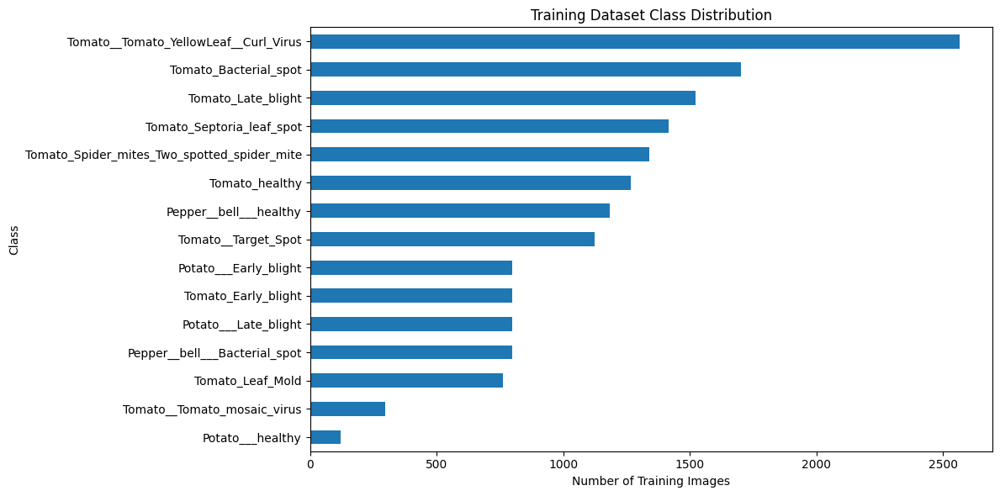

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training data
train_df = pd.read_csv(
    "/kaggle/input/datasets/ankaprian/diseaseleafclassifier-metadata/train.csv"
)

# Count images per class
class_counts = train_df["class_name"].value_counts()

print("Number of classes:", len(class_counts))
print("\nClass distribution:")
print(class_counts)

# Plot
plt.figure(figsize=(12, 6))

class_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of Training Images")
plt.ylabel("Class")
plt.title("Training Dataset Class Distribution")

plt.tight_layout()
plt.show()

In [11]:
train_df = pd.read_csv(
    "/kaggle/input/datasets/ankaprian/diseaseleafclassifier-metadata/train.csv"
)

val_df = pd.read_csv(
    "/kaggle/input/datasets/ankaprian/diseaseleafclassifier-metadata/validation.csv"
)

test_df = pd.read_csv(
    "/kaggle/input/datasets/ankaprian/diseaseleafclassifier-metadata/test.csv"
)

print("TRAIN DISTRIBUTION")
print((train_df["class_name"].value_counts(normalize=True) * 100).round(2))

print("\nVALIDATION DISTRIBUTION")
print((val_df["class_name"].value_counts(normalize=True) * 100).round(2))

print("\nTEST DISTRIBUTION")
print((test_df["class_name"].value_counts(normalize=True) * 100).round(2))

TRAIN DISTRIBUTION
class_name
Tomato__Tomato_YellowLeaf__Curl_Virus          15.55
Tomato_Bacterial_spot                          10.31
Tomato_Late_blight                              9.22
Tomato_Septoria_leaf_spot                       8.59
Tomato_Spider_mites_Two_spotted_spider_mite     8.13
Tomato_healthy                                  7.69
Pepper__bell___healthy                          7.16
Tomato__Target_Spot                             6.81
Tomato_Early_blight                             4.85
Potato___Late_blight                            4.85
Potato___Early_blight                           4.85
Pepper__bell___Bacterial_spot                   4.84
Tomato_Leaf_Mold                                4.62
Tomato__Tomato_mosaic_virus                     1.81
Potato___healthy                                0.74
Name: proportion, dtype: float64

VALIDATION DISTRIBUTION
class_name
Tomato__Tomato_YellowLeaf__Curl_Virus          15.57
Tomato_Bacterial_spot                          10.33


In [12]:
import os
import pandas as pd
import tensorflow as tf

# ==========================================
# PATHS
# ==========================================

IMAGE_ROOT = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
META_ROOT = "/kaggle/input/datasets/ankaprian/diseaseleafclassifier-metadata"

TRAIN_CSV = os.path.join(META_ROOT, "train.csv")
VAL_CSV   = os.path.join(META_ROOT, "validation.csv")
TEST_CSV  = os.path.join(META_ROOT, "test.csv")

# ==========================================
# CONFIGURATION
# ==========================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 15

# ==========================================
# LOAD CSVs
# ==========================================

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nClasses:", train_df["class_name"].nunique())
print(train_df["class_name"].unique())

Train: (16499, 2)
Validation: (2062, 2)
Test: (2063, 2)

Classes: 15
['Tomato__Tomato_YellowLeaf__Curl_Virus' 'Tomato_Bacterial_spot'
 'Tomato_healthy' 'Tomato_Late_blight'
 'Tomato_Spider_mites_Two_spotted_spider_mite' 'Tomato_Early_blight'
 'Tomato_Septoria_leaf_spot' 'Tomato__Target_Spot'
 'Pepper__bell___Bacterial_spot' 'Potato___Early_blight'
 'Potato___Late_blight' 'Tomato_Leaf_Mold' 'Pepper__bell___healthy'
 'Potato___healthy' 'Tomato__Tomato_mosaic_virus']


In [13]:
# ==========================================
# BUILD IMAGE PATH INDEX
# ==========================================

image_paths = {}

for root, dirs, files in os.walk(IMAGE_ROOT):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths[file] = os.path.join(root, file)

print("Indexed images:", len(image_paths))

# Add actual image path to each dataframe
train_df["filepath"] = train_df["image_name"].map(image_paths)
val_df["filepath"] = val_df["image_name"].map(image_paths)
test_df["filepath"] = test_df["image_name"].map(image_paths)

print("\nMissing train paths:", train_df["filepath"].isna().sum())
print("Missing validation paths:", val_df["filepath"].isna().sum())
print("Missing test paths:", test_df["filepath"].isna().sum())

Indexed images: 20638

Missing train paths: 0
Missing validation paths: 0
Missing test paths: 0


In [14]:
# ==========================================
# CLASS MAPPING
# ==========================================

class_names = sorted(train_df["class_name"].unique())

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print("Class mapping:\n")

for index, class_name in index_to_class.items():
    print(index, "->", class_name)

# Add numerical labels
train_df["label"] = train_df["class_name"].map(class_to_index)
val_df["label"] = val_df["class_name"].map(class_to_index)
test_df["label"] = test_df["class_name"].map(class_to_index)

Class mapping:

0 -> Pepper__bell___Bacterial_spot
1 -> Pepper__bell___healthy
2 -> Potato___Early_blight
3 -> Potato___Late_blight
4 -> Potato___healthy
5 -> Tomato_Bacterial_spot
6 -> Tomato_Early_blight
7 -> Tomato_Late_blight
8 -> Tomato_Leaf_Mold
9 -> Tomato_Septoria_leaf_spot
10 -> Tomato_Spider_mites_Two_spotted_spider_mite
11 -> Tomato__Target_Spot
12 -> Tomato__Tomato_YellowLeaf__Curl_Virus
13 -> Tomato__Tomato_mosaic_virus
14 -> Tomato_healthy


In [15]:
# ==========================================
# BUILD IMAGE PATH INDEX
# ==========================================

image_paths = {}

for root, dirs, files in os.walk(IMAGE_ROOT):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths[file] = os.path.join(root, file)

print("Indexed images:", len(image_paths))

# Add actual image path
train_df["filepath"] = train_df["image_name"].map(image_paths)
val_df["filepath"] = val_df["image_name"].map(image_paths)
test_df["filepath"] = test_df["image_name"].map(image_paths)

print("Missing train paths:", train_df["filepath"].isna().sum())
print("Missing validation paths:", val_df["filepath"].isna().sum())
print("Missing test paths:", test_df["filepath"].isna().sum())

Indexed images: 20638
Missing train paths: 0
Missing validation paths: 0
Missing test paths: 0


In [16]:
# ==========================================
# IMAGE LOADING FUNCTION
# ==========================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label

In [17]:
# ==========================================
# CREATE TF.DATA DATASETS
# ==========================================

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["filepath"].values,
        train_df["label"].values
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["filepath"].values,
        val_df["label"].values
    )
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["filepath"].values,
        test_df["label"].values
    )
)

# Training: shuffle
train_ds = (
    train_ds
    .shuffle(len(train_df), seed=42)
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation
val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Test
test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets created successfully.")

I0000 00:00:1790941066.775660      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790941066.779464      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets created successfully.


In [18]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)

print(
    "Pixel range:",
    tf.reduce_min(images).numpy(),
    "to",
    tf.reduce_max(images).numpy()
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Pixel range: 0.0 to 252.56618


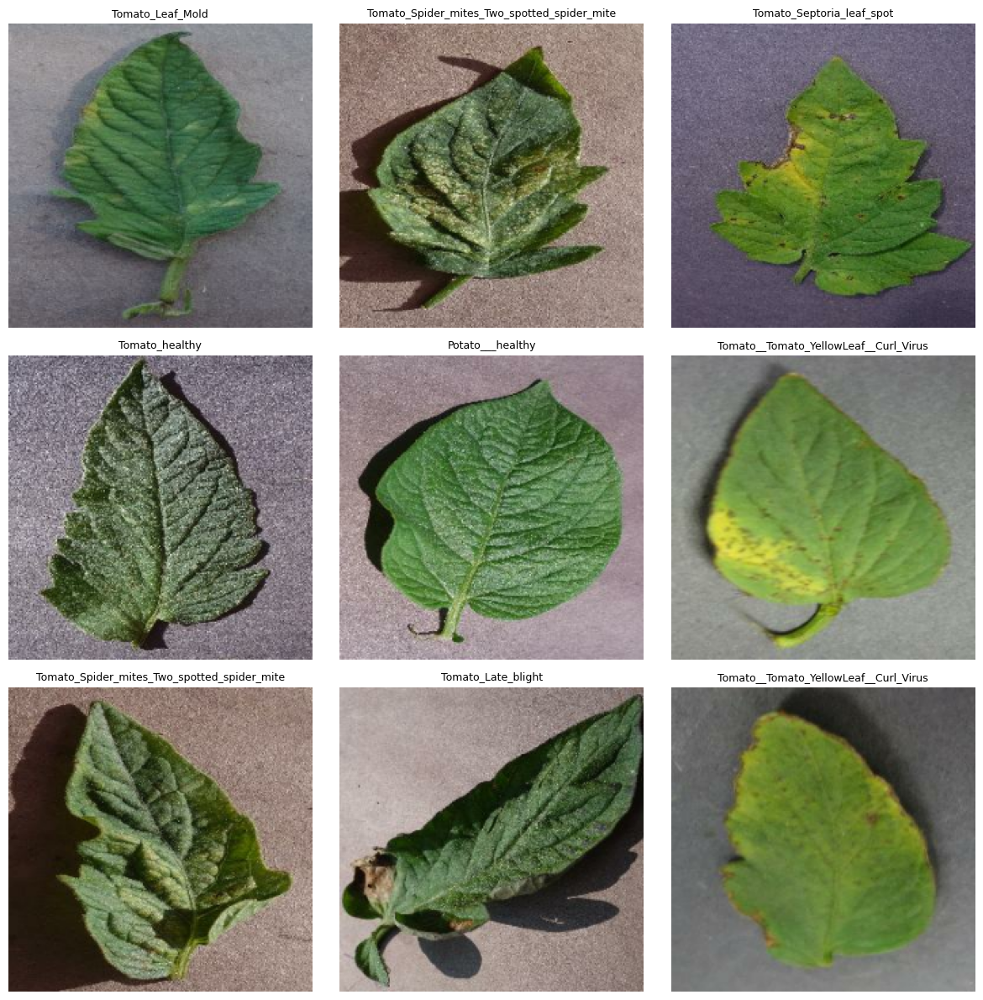

In [19]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    class_name = index_to_class[int(labels[i].numpy())]

    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# DATA AUGMENTATION
# ==========================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.08
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
], name="data_augmentation")

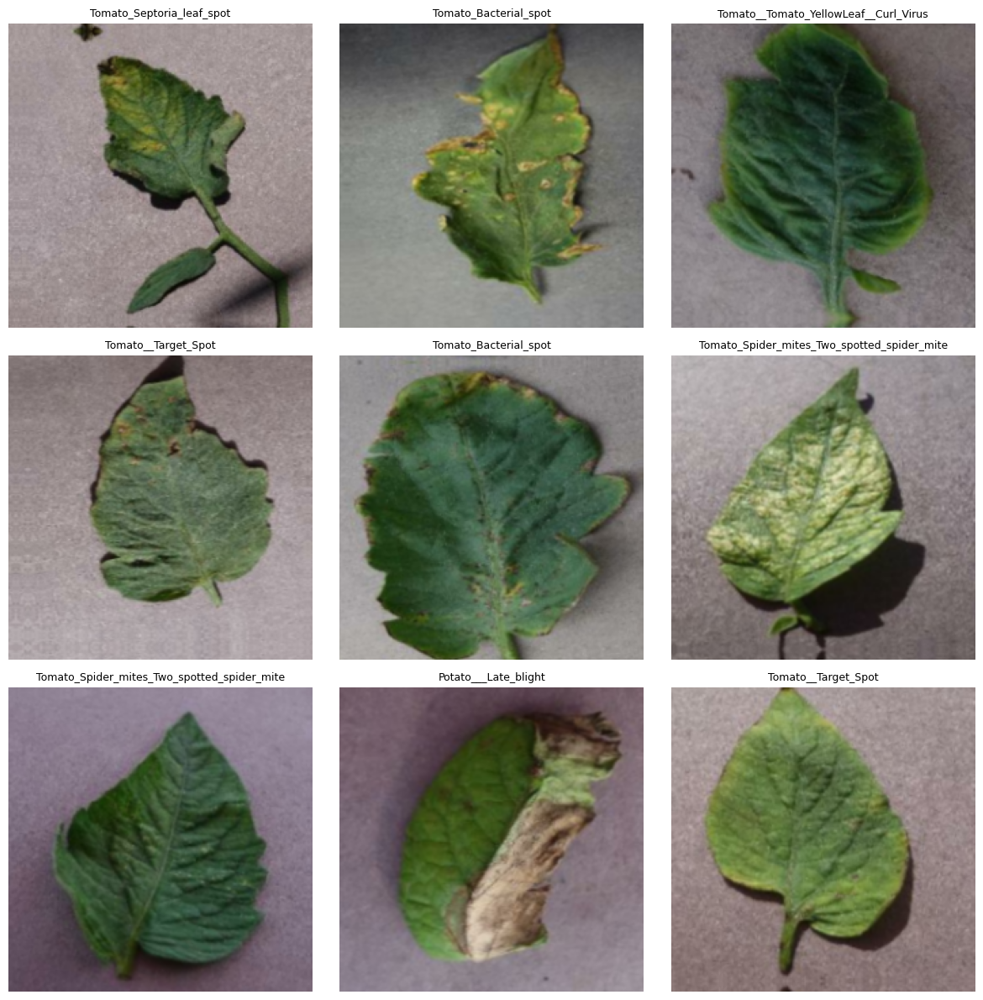

In [21]:
# ==========================================
# VISUALIZE AUGMENTATION
# ==========================================

sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(12, 12))

for i in range(9):

    augmented = data_augmentation(
        sample_images[i:i+1],
        training=True
    )

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        tf.clip_by_value(
            augmented[0],
            0,
            255
        ).numpy().astype("uint8")
    )

    class_name = index_to_class[
        int(sample_labels[i].numpy())
    ]

    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# ==========================================
# MobileNetV3-Small - BASELINE MODEL
# ==========================================

import tensorflow as tf

NUM_CLASSES = 15
IMG_SIZE = (224, 224)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
], name="data_augmentation")


# Pretrained MobileNetV3-Small
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True
)

# Freeze the pretrained backbone
base_model.trainable = False


# Build complete model
inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="DiseaseLeafClassifier_MobileNetV3Small"
)

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "DiseaseLeafClassifier_MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 15)             │         8,655 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 947,775 (3.62 MB)

 Trainable params: 8,655 (33.81 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [23]:
# ==========================================
# COMPILE BASELINE MODEL
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [24]:
# ==========================================
# CALLBACKS
# ==========================================

checkpoint_path = "/kaggle/working/best_mobilenetv3_baseline.keras"

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [25]:
# ==========================================
# CLASS WEIGHTS
# ==========================================

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(NUM_CLASSES)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, class_weights_array)
}

print("Class weights:")

for class_id, weight in class_weights.items():
    print(
        class_id,
        "->",
        index_to_class[class_id],
        ":",
        round(weight, 3)
    )

Class weights:
0 -> Pepper__bell___Bacterial_spot : 1.378
1 -> Pepper__bell___healthy : 0.931
2 -> Potato___Early_blight : 1.375
3 -> Potato___Late_blight : 1.375
4 -> Potato___healthy : 9.016
5 -> Tomato_Bacterial_spot : 0.647
6 -> Tomato_Early_blight : 1.375
7 -> Tomato_Late_blight : 0.723
8 -> Tomato_Leaf_Mold : 1.443
9 -> Tomato_Septoria_leaf_spot : 0.776
10 -> Tomato_Spider_mites_Two_spotted_spider_mite : 0.82
11 -> Tomato__Target_Spot : 0.979
12 -> Tomato__Tomato_YellowLeaf__Curl_Virus : 0.429
13 -> Tomato__Tomato_mosaic_virus : 3.691
14 -> Tomato_healthy : 0.867


In [26]:
# ==========================================
# TRAIN BASELINE
# ==========================================

EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4694 - loss: 1.7757
Epoch 1: val_accuracy improved from None to 0.81038, saving model to /kaggle/working/best_mobilenetv3_baseline.keras

Epoch 1: finished saving model to /kaggle/working/best_mobilenetv3_baseline.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 59s 99ms/step - accuracy: 0.6521 - loss: 1.2005 - val_accuracy: 0.8104 - val_loss: 0.6559 - learning_rate: 0.0010
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8150 - loss: 0.6264
Epoch 2: val_accuracy improved from 0.81038 to 0.84433, saving model to /kaggle/working/best_mobilenetv3_baseline.keras

Epoch 2: finished saving model to /kaggle/working/best_mobilenetv3_baseline.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.8271 - loss: 0.5785 - val_accuracy: 0.8443 - val_loss: 0.5028 - learning_rate: 0.0010
Epoch 3/15
515/516 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8504 - loss: 0.4694
Epoch 3: val_accuracy improved from 0.84433 to 0.8

In [27]:
# ==========================================
# TEST SET EVALUATION
# ==========================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Evaluate directly
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.9094 - loss: 0.2929

Test Loss: 0.29292237758636475
Test Accuracy: 0.9093552827835083


In [28]:
# ==========================================
# TEST PREDICTIONS
# ==========================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ==========================================
# OVERALL METRICS
# ==========================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("===================================")
print("TEST RESULTS")
print("===================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

TEST RESULTS
Accuracy : 0.9094
Precision: 0.9170
Recall   : 0.9094
F1 Score : 0.9107


In [29]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9515    0.9899    0.9703        99
                     Pepper__bell___healthy     0.9608    0.9932    0.9767       148
                      Potato___Early_blight     0.9429    0.9900    0.9659       100
                       Potato___Late_blight     0.8571    0.9000    0.8780       100
                           Potato___healthy     0.4545    1.0000    0.6250        15
                      Tomato_Bacterial_spot     0.9143    0.9014    0.9078       213
                        Tomato_Early_blight     0.8987    0.7100    0.7933       100
                         Tomato_Late_blight     0.9135    0.8895    0.9013       190
                           Tomato_Leaf_Mold     0.9630    0.8211    0.8864        95
                  Tomato_Septoria_leaf_spot     0.9313    0.8418    0.8843       177
Tomato_Spider_mites_Two_spotted_spider_mite     0.8785    0.9464

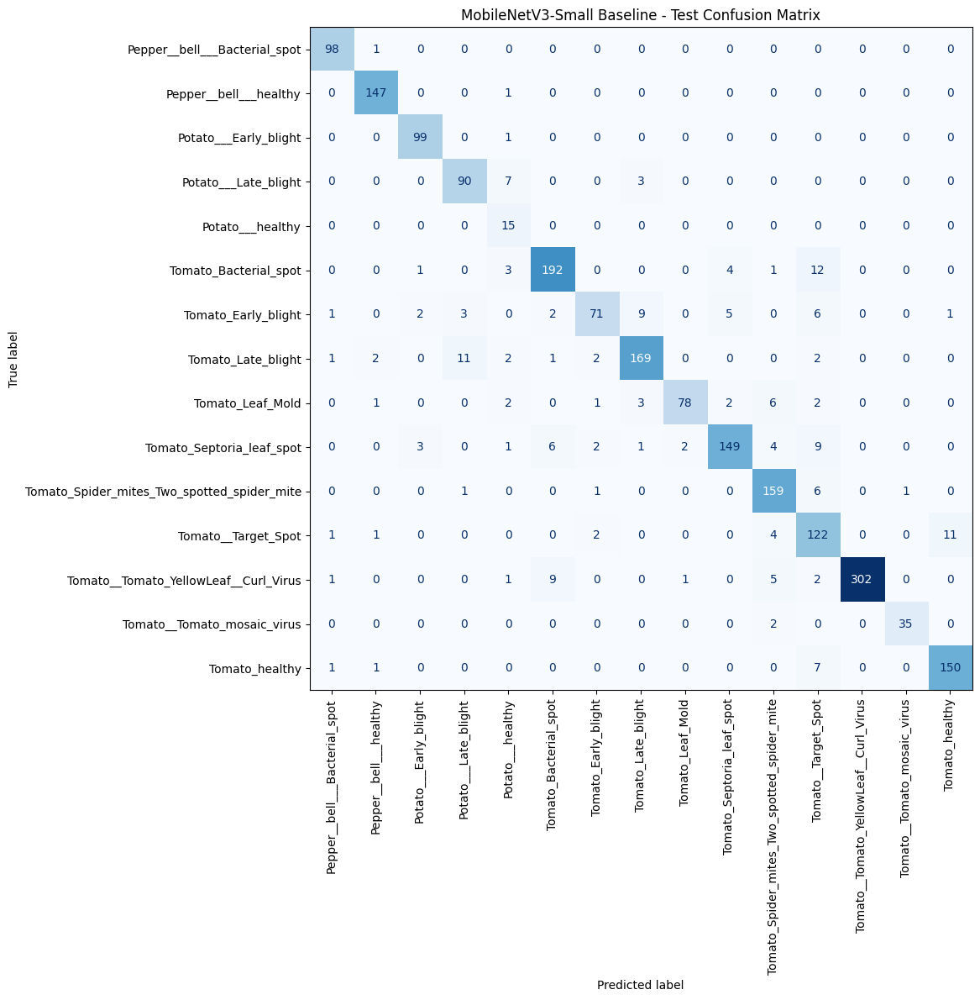

In [30]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("MobileNetV3-Small Baseline - Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [31]:
import os

baseline_size_mb = os.path.getsize(
    "/kaggle/working/best_mobilenetv3_baseline.keras"
) / (1024 ** 2)

print(f"Baseline model size: {baseline_size_mb:.2f} MB")

Baseline model size: 4.24 MB


In [32]:
import time
import numpy as np

# Take one batch and one image
sample_images, _ = next(iter(test_ds))
sample_image = sample_images[:1]

# Warm-up
for _ in range(10):
    _ = model(sample_image, training=False)

# Measure
times = []

for _ in range(50):
    start = time.perf_counter()

    _ = model(sample_image, training=False)

    end = time.perf_counter()

    times.append((end - start) * 1000)

print(f"Average inference time: {np.mean(times):.2f} ms")
print(f"Median inference time: {np.median(times):.2f} ms")

Average inference time: 142.16 ms
Median inference time: 141.09 ms


In [33]:
# ==========================================
# FINE-TUNING SETUP
# ==========================================

base_model.trainable = True

# Freeze earlier layers
fine_tune_from = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# Keep BatchNorm layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total MobileNetV3 layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_from)

trainable_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print("Trainable layers:", len(trainable_layers))
print(trainable_layers)

Total MobileNetV3 layers: 157
Fine-tuning from layer: 127
Trainable layers: 24
['expanded_conv_9_depthwise', 'activation_14', 'expanded_conv_9_squeeze_excite_avg_pool', 'expanded_conv_9_squeeze_excite_conv', 'expanded_conv_9_squeeze_excite_relu', 'expanded_conv_9_squeeze_excite_conv_1', 're_lu_12', 'expanded_conv_9_squeeze_excite_mul', 'expanded_conv_9_project', 'expanded_conv_9_add', 'expanded_conv_10_expand', 'activation_15', 'expanded_conv_10_depthwise', 'activation_16', 'expanded_conv_10_squeeze_excite_avg_pool', 'expanded_conv_10_squeeze_excite_conv', 'expanded_conv_10_squeeze_excite_relu', 'expanded_conv_10_squeeze_excite_conv_1', 're_lu_13', 'expanded_conv_10_squeeze_excite_mul', 'expanded_conv_10_project', 'expanded_conv_10_add', 'conv_1', 'activation_17']


In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled.")

Fine-tuning model compiled.


In [35]:
fine_tune_checkpoint = (
    "/kaggle/working/"
    "best_mobilenetv3_finetuned.keras"
)

fine_tune_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        fine_tune_checkpoint,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [36]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9127 - loss: 0.2471
Epoch 1: val_accuracy improved from None to 0.90980, saving model to /kaggle/working/best_mobilenetv3_finetuned.keras

Epoch 1: finished saving model to /kaggle/working/best_mobilenetv3_finetuned.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.9141 - loss: 0.2429 - val_accuracy: 0.9098 - val_loss: 0.2658 - learning_rate: 1.0000e-05
Epoch 2/10
515/516 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9212 - loss: 0.2190
Epoch 2: val_accuracy did not improve from 0.90980
516/516 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.9208 - loss: 0.2212 - val_accuracy: 0.9088 - val_loss: 0.2612 - learning_rate: 1.0000e-05
Epoch 3/10
515/516 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9246 - loss: 0.2169
Epoch 3: val_accuracy improved from 0.90980 to 0.91562, saving model to /kaggle/working/best_mobilenetv3_finetuned.keras

Epoch 3: finished saving model to /kaggle/working/best_mobilenetv3_fin

In [37]:
# ==========================================
# FINE-TUNED MODEL - TEST EVALUATION
# ==========================================

fine_test_loss, fine_test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\nFine-tuned Test Loss:", fine_test_loss)
print("Fine-tuned Test Accuracy:", fine_test_accuracy)

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9331 - loss: 0.2115

Fine-tuned Test Loss: 0.21150192618370056
Fine-tuned Test Accuracy: 0.9331071376800537


In [38]:
# ==========================================
# FINE-TUNED TEST PREDICTIONS
# ==========================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend(predicted_labels)

y_true_ft = np.array(y_true_ft)
y_pred_ft = np.array(y_pred_ft)

# Metrics
accuracy_ft = accuracy_score(y_true_ft, y_pred_ft)

precision_ft = precision_score(
    y_true_ft,
    y_pred_ft,
    average="weighted",
    zero_division=0
)

recall_ft = recall_score(
    y_true_ft,
    y_pred_ft,
    average="weighted",
    zero_division=0
)

f1_ft = f1_score(
    y_true_ft,
    y_pred_ft,
    average="weighted",
    zero_division=0
)

print("===================================")
print("FINE-TUNED TEST RESULTS")
print("===================================")

print(f"Accuracy : {accuracy_ft:.4f}")
print(f"Precision: {precision_ft:.4f}")
print(f"Recall   : {recall_ft:.4f}")
print(f"F1 Score : {f1_ft:.4f}")

FINE-TUNED TEST RESULTS
Accuracy : 0.9331
Precision: 0.9360
Recall   : 0.9331
F1 Score : 0.9334


In [39]:
# ==========================================
# FINE-TUNED CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_true_ft,
        y_pred_ft,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9703    0.9899    0.9800        99
                     Pepper__bell___healthy     0.9866    0.9932    0.9899       148
                      Potato___Early_blight     0.9804    1.0000    0.9901       100
                       Potato___Late_blight     0.9020    0.9200    0.9109       100
                           Potato___healthy     0.6818    1.0000    0.8108        15
                      Tomato_Bacterial_spot     0.9655    0.9202    0.9423       213
                        Tomato_Early_blight     0.8977    0.7900    0.8404       100
                         Tomato_Late_blight     0.9402    0.9105    0.9251       190
                           Tomato_Leaf_Mold     0.9663    0.9053    0.9348        95
                  Tomato_Septoria_leaf_spot     0.9310    0.9153    0.9231       177
Tomato_Spider_mites_Two_spotted_spider_mite     0.9249    0.9524

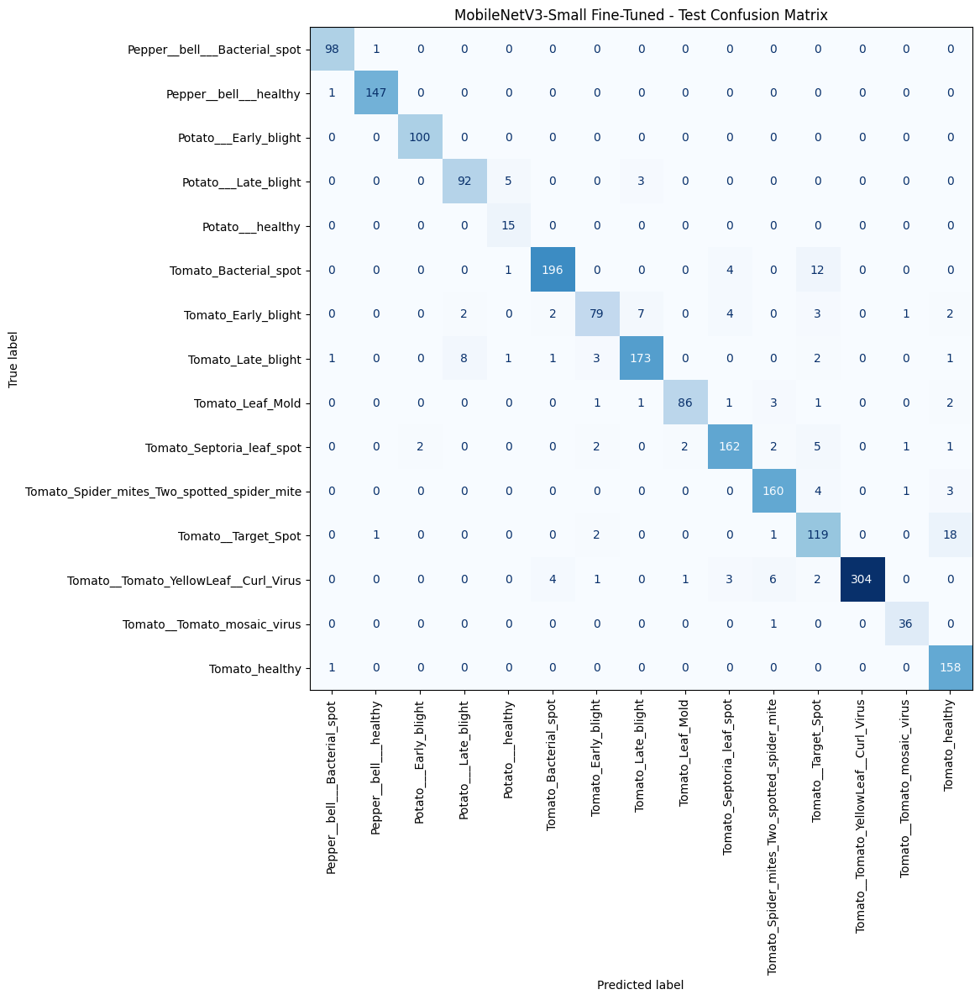

In [40]:
# ==========================================
# FINE-TUNED CONFUSION MATRIX
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_ft = confusion_matrix(
    y_true_ft,
    y_pred_ft
)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "MobileNetV3-Small Fine-Tuned - Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

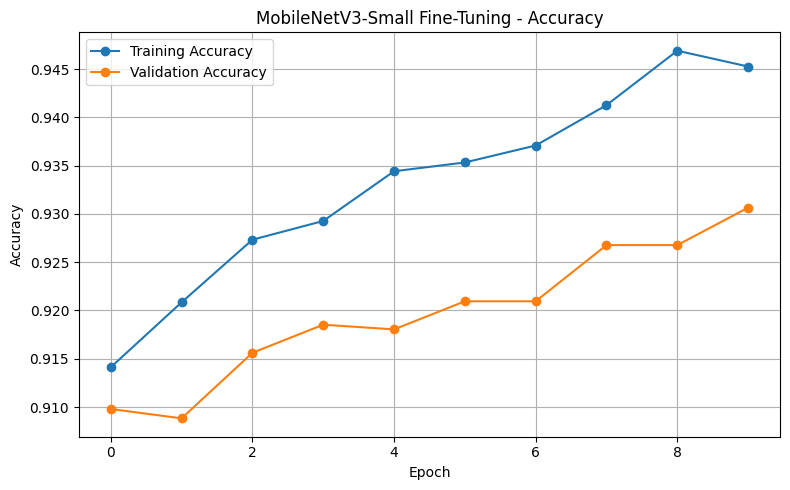

In [41]:
# ==========================================
# FINE-TUNING ACCURACY CURVE
# ==========================================

import matplotlib.pyplot as plt

history_dict = fine_tune_history.history

plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_dict["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("MobileNetV3-Small Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

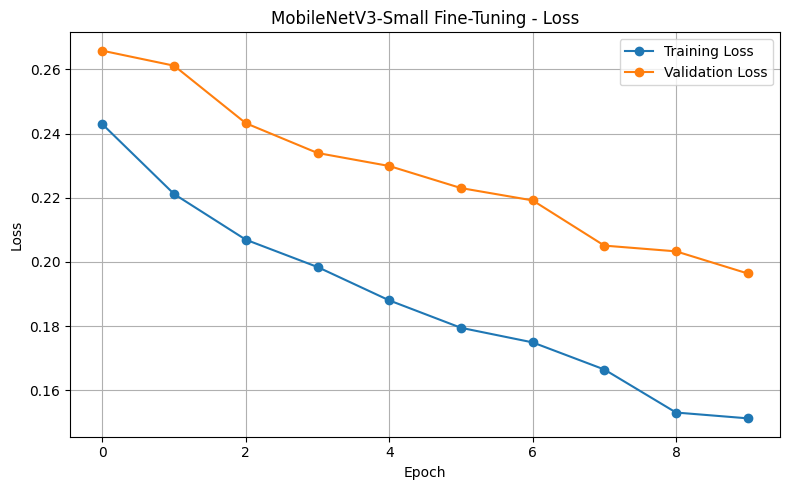

In [42]:
# ==========================================
# FINE-TUNING LOSS CURVE
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_dict["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("MobileNetV3-Small Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Best Epoch: 10
Best Validation Accuracy: 0.9306498765945435


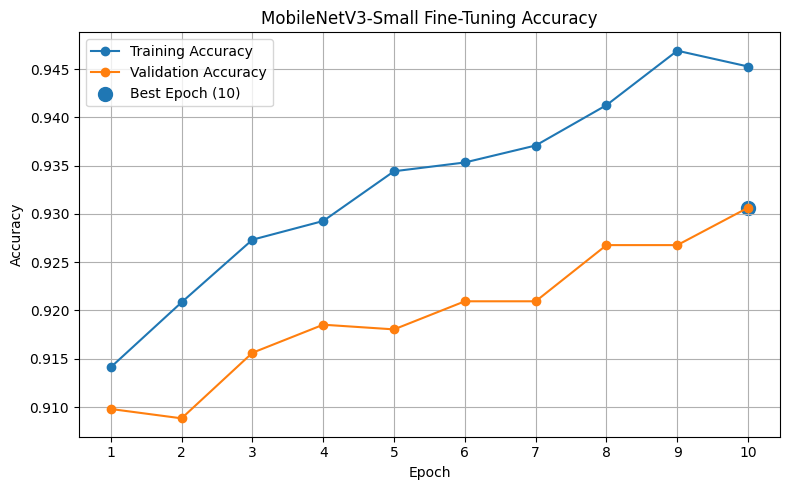

In [43]:
# ==========================================
# MARK BEST VALIDATION ACCURACY
# ==========================================

best_epoch = (
    max(
        range(len(history_dict["val_accuracy"])),
        key=lambda i: history_dict["val_accuracy"][i]
    )
)

best_val_accuracy = history_dict["val_accuracy"][best_epoch]

print("Best Epoch:", best_epoch + 1)
print("Best Validation Accuracy:", best_val_accuracy)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history_dict["accuracy"]) + 1),
    history_dict["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(1, len(history_dict["val_accuracy"]) + 1),
    history_dict["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.scatter(
    best_epoch + 1,
    best_val_accuracy,
    s=100,
    label=f"Best Epoch ({best_epoch + 1})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV3-Small Fine-Tuning Accuracy")
plt.xticks(range(1, len(history_dict["accuracy"]) + 1))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [44]:
# ==========================================
# SAVE FINAL FINE-TUNED FP32 MODEL
# ==========================================

FINAL_MODEL_PATH = "/kaggle/working/final_mobilenetv3_finetuned.keras"

model.save(FINAL_MODEL_PATH)

print("Final FP32 model saved successfully.")
print(FINAL_MODEL_PATH)

Final FP32 model saved successfully.
/kaggle/working/final_mobilenetv3_finetuned.keras


In [45]:
import os

size_mb = os.path.getsize(FINAL_MODEL_PATH) / (1024 ** 2)

print(f"FP32 Keras model size: {size_mb:.2f} MB")

FP32 Keras model size: 8.70 MB


In [46]:
import json

CLASS_MAP_PATH = "/kaggle/working/class_mapping.json"

with open(CLASS_MAP_PATH, "w") as f:
    json.dump(index_to_class, f, indent=4)

print("Class mapping saved.")

Class mapping saved.


In [47]:
# ==========================================
# KERAS → TFLITE FP32
# ==========================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

FP32_TFLITE_PATH = "/kaggle/working/mobilenetv3_fp32.tflite"

with open(FP32_TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize(FP32_TFLITE_PATH) / (1024 ** 2)

print(f"TFLite FP32 model size: {size_mb:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpt7a4vvq7/assets


INFO:tensorflow:Assets written to: /tmp/tmpt7a4vvq7/assets


Saved artifact at '/tmp/tmpt7a4vvq7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  136256770158672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882583952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882586832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882588560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882583184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882588368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882585104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882581264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882578192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882587984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13625688258721

W0000 00:00:1790941555.008993      23 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790941555.009023      23 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790941555.103905      23 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


In [48]:
# ==========================================
# VERIFY TFLITE MODEL
# ==========================================

interpreter = tf.lite.Interpreter(
    model_path=FP32_TFLITE_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUT")
print("Shape:", input_details[0]["shape"])
print("dtype:", input_details[0]["dtype"])

print("\nOUTPUT")
print("Shape:", output_details[0]["shape"])
print("dtype:", output_details[0]["dtype"])

INPUT
Shape: [  1 224 224   3]
dtype: <class 'numpy.float32'>

OUTPUT
Shape: [ 1 15]
dtype: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [49]:
# ==========================================
# TEST ONE TFLITE PREDICTION
# ==========================================

sample_images, sample_labels = next(iter(test_ds))

sample_image = sample_images[0:1]

# Set input
interpreter.set_tensor(
    input_details[0]["index"],
    sample_image.numpy()
)

# Inference
interpreter.invoke()

# Get prediction
output = interpreter.get_tensor(
    output_details[0]["index"]
)

predicted_class = np.argmax(output[0])
confidence = float(output[0][predicted_class])

actual_class = int(sample_labels[0].numpy())

print("Actual class:")
print(index_to_class[actual_class])

print("\nPredicted class:")
print(index_to_class[predicted_class])

print(f"\nConfidence: {confidence:.4f}")

Actual class:
Pepper__bell___healthy

Predicted class:
Pepper__bell___healthy

Confidence: 0.9687


In [50]:
# ==========================================
# REPRESENTATIVE DATASET FOR INT8
# ==========================================

def representative_dataset():
    for images, labels in train_ds.take(100):
        for i in range(images.shape[0]):
            image = images[i:i+1]

            yield [image.numpy().astype(np.float32)]

print("Representative dataset function ready.")

Representative dataset function ready.


In [51]:
# ==========================================
# FULL INT8 QUANTIZATION
# ==========================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

int8_model = converter.convert()

INT8_TFLITE_PATH = "/kaggle/working/mobilenetv3_int8.tflite"

with open(INT8_TFLITE_PATH, "wb") as f:
    f.write(int8_model)

size_mb = os.path.getsize(INT8_TFLITE_PATH) / (1024 ** 2)

print(f"INT8 TFLite model size: {size_mb:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmps6xsaws5/assets


INFO:tensorflow:Assets written to: /tmp/tmps6xsaws5/assets


Saved artifact at '/tmp/tmps6xsaws5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  136256770158672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882583952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882586832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882588560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882583184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882588368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882585104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882581264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882578192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882587984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13625688258721

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1790941565.243326      23 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790941565.243350      23 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


INT8 TFLite model size: 1.18 MB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [52]:
# ==========================================
# VERIFY INT8 MODEL WITHOUT XNNPACK
# ==========================================

int8_interpreter = tf.lite.Interpreter(
    model_path=INT8_TFLITE_PATH,
    experimental_op_resolver_type=(
        tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
    )
)

int8_interpreter.allocate_tensors()

int8_input = int8_interpreter.get_input_details()[0]
int8_output = int8_interpreter.get_output_details()[0]

print("INPUT")
print("Shape:", int8_input["shape"])
print("dtype:", int8_input["dtype"])
print("quantization:", int8_input["quantization"])

print("\nOUTPUT")
print("Shape:", int8_output["shape"])
print("dtype:", int8_output["dtype"])
print("quantization:", int8_output["quantization"])

INPUT
Shape: [  1 224 224   3]
dtype: <class 'numpy.int8'>
quantization: (1.0, -128)

OUTPUT
Shape: [ 1 15]
dtype: <class 'numpy.int8'>
quantization: (0.00390625, -128)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [53]:
import numpy as np

# Take one image from test dataset
sample_images, sample_labels = next(iter(test_ds.take(1)))

sample_image = sample_images[0:1]
true_label = int(sample_labels[0].numpy())

# Get quantization parameters
input_scale, input_zero_point = int8_input["quantization"]
output_scale, output_zero_point = int8_output["quantization"]

# Quantize input
quantized_image = np.round(
    sample_image.numpy() / input_scale + input_zero_point
)

quantized_image = np.clip(
    quantized_image, -128, 127
).astype(np.int8)

# Set input
int8_interpreter.set_tensor(
    int8_input["index"],
    quantized_image
)

# Run inference
int8_interpreter.invoke()

# Get INT8 output
raw_output = int8_interpreter.get_tensor(
    int8_output["index"]
)

# Dequantize output
output_float = (
    raw_output.astype(np.float32) - output_zero_point
) * output_scale

# Prediction
predicted_class = np.argmax(output_float[0])
confidence = output_float[0][predicted_class]

print("True class     :", class_names[true_label])
print("Predicted class:", class_names[predicted_class])
print("Confidence     :", round(float(confidence), 4))

True class     : Pepper__bell___healthy
Predicted class: Pepper__bell___Bacterial_spot
Confidence     : 0.9688


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

y_true_int8 = []
y_pred_int8 = []

for images, labels in test_ds:

    for i in range(images.shape[0]):

        # Get one image
        image = images[i:i+1]

        # Quantize input
        quantized_image = np.round(
            image.numpy() / input_scale + input_zero_point
        )

        quantized_image = np.clip(
            quantized_image, -128, 127
        ).astype(np.int8)

        # Run INT8 inference
        int8_interpreter.set_tensor(
            int8_input["index"],
            quantized_image
        )

        int8_interpreter.invoke()

        # Get output
        raw_output = int8_interpreter.get_tensor(
            int8_output["index"]
        )

        # Dequantize output
        output_float = (
            raw_output.astype(np.float32) - output_zero_point
        ) * output_scale

        predicted_class = np.argmax(output_float[0])

        y_true_int8.append(int(labels[i].numpy()))
        y_pred_int8.append(predicted_class)

# Calculate metrics
accuracy_int8 = accuracy_score(y_true_int8, y_pred_int8)

precision_int8 = precision_score(
    y_true_int8,
    y_pred_int8,
    average="weighted",
    zero_division=0
)

recall_int8 = recall_score(
    y_true_int8,
    y_pred_int8,
    average="weighted",
    zero_division=0
)

f1_int8 = f1_score(
    y_true_int8,
    y_pred_int8,
    average="weighted",
    zero_division=0
)

print("========== INT8 TEST RESULTS ==========")
print(f"Accuracy : {accuracy_int8:.4f}")
print(f"Precision: {precision_int8:.4f}")
print(f"Recall   : {recall_int8:.4f}")
print(f"F1 Score : {f1_int8:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_true_int8,
        y_pred_int8,
        target_names=class_names,
        zero_division=0
    )
)

========== INT8 TEST RESULTS ==========
Accuracy : 0.5322
Precision: 0.8198
Recall   : 0.5322
F1 Score : 0.5601

Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.47      0.99      0.63        99
                     Pepper__bell___healthy       0.99      0.64      0.78       148
                      Potato___Early_blight       0.49      0.99      0.66       100
                       Potato___Late_blight       0.79      0.38      0.51       100
                           Potato___healthy       0.80      0.80      0.80        15
                      Tomato_Bacterial_spot       0.94      0.28      0.43       213
                        Tomato_Early_blight       0.13      0.93      0.22       100
                         Tomato_Late_blight       0.88      0.49      0.63       190
                           Tomato_Leaf_Mold       0.69      0.71      0.70        95
            

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf

# Load FP32 TFLite model
fp32_interpreter = tf.lite.Interpreter(
    model_path="/kaggle/working/mobilenetv3_fp32.tflite",
    experimental_op_resolver_type=(
        tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
    )
)

fp32_interpreter.allocate_tensors()

fp32_input = fp32_interpreter.get_input_details()[0]
fp32_output = fp32_interpreter.get_output_details()[0]

print("FP32 INPUT")
print("Shape:", fp32_input["shape"])
print("dtype:", fp32_input["dtype"])

print("\nFP32 OUTPUT")
print("Shape:", fp32_output["shape"])
print("dtype:", fp32_output["dtype"])


y_true_fp32 = []
y_pred_fp32 = []

for images, labels in test_ds:

    for i in range(images.shape[0]):

        image = images[i:i+1].numpy().astype(np.float32)

        fp32_interpreter.set_tensor(
            fp32_input["index"],
            image
        )

        fp32_interpreter.invoke()

        output = fp32_interpreter.get_tensor(
            fp32_output["index"]
        )

        predicted_class = np.argmax(output[0])

        y_true_fp32.append(int(labels[i].numpy()))
        y_pred_fp32.append(predicted_class)


accuracy_fp32_tflite = accuracy_score(
    y_true_fp32,
    y_pred_fp32
)

precision_fp32_tflite = precision_score(
    y_true_fp32,
    y_pred_fp32,
    average="weighted",
    zero_division=0
)

recall_fp32_tflite = recall_score(
    y_true_fp32,
    y_pred_fp32,
    average="weighted",
    zero_division=0
)

f1_fp32_tflite = f1_score(
    y_true_fp32,
    y_pred_fp32,
    average="weighted",
    zero_division=0
)

print("\n========== FP32 TFLITE RESULTS ==========")
print(f"Accuracy : {accuracy_fp32_tflite:.4f}")
print(f"Precision: {precision_fp32_tflite:.4f}")
print(f"Recall   : {recall_fp32_tflite:.4f}")
print(f"F1 Score : {f1_fp32_tflite:.4f}")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


FP32 INPUT
Shape: [  1 224 224   3]
dtype: <class 'numpy.float32'>

FP32 OUTPUT
Shape: [ 1 15]
dtype: <class 'numpy.float32'>

========== FP32 TFLITE RESULTS ==========
Accuracy : 0.9331
Precision: 0.9360
Recall   : 0.9331
F1 Score : 0.9334


In [56]:
# Take exactly one test image
sample_images, sample_labels = next(iter(test_ds))

sample_image = sample_images[0:1].numpy().astype(np.float32)
true_label = int(sample_labels[0].numpy())

print("True class:", class_names[true_label])


# ============================================================
# 1. FP32 TFLite prediction
# ============================================================

fp32_interpreter.set_tensor(
    fp32_input["index"],
    sample_image
)

fp32_interpreter.invoke()

fp32_result = fp32_interpreter.get_tensor(
    fp32_output["index"]
)

fp32_pred = np.argmax(fp32_result[0])

print("\nFP32 TFLite")
print("Predicted:", class_names[fp32_pred])
print("Confidence:", round(float(fp32_result[0][fp32_pred]), 4))


# ============================================================
# 2. INT8 TFLite prediction
# ============================================================

quantized_image = np.round(
    sample_image / input_scale + input_zero_point
)

quantized_image = np.clip(
    quantized_image,
    -128,
    127
).astype(np.int8)

int8_interpreter.set_tensor(
    int8_input["index"],
    quantized_image
)

int8_interpreter.invoke()

raw_int8_result = int8_interpreter.get_tensor(
    int8_output["index"]
)

int8_result = (
    raw_int8_result.astype(np.float32)
    - output_zero_point
) * output_scale

int8_pred = np.argmax(int8_result[0])

print("\nINT8 TFLite")
print("Predicted:", class_names[int8_pred])
print("Confidence:", round(float(int8_result[0][int8_pred]), 4))

True class: Pepper__bell___healthy

FP32 TFLite
Predicted: Pepper__bell___healthy
Confidence: 0.9687

INT8 TFLite
Predicted: Pepper__bell___Bacterial_spot
Confidence: 0.9688


In [57]:
import tensorflow as tf
import numpy as np
import os

# ---------------------------------------------------------
# 1. Representative dataset
# ---------------------------------------------------------

def representative_dataset():
    count = 0

    for images, labels in train_ds:

        for i in range(images.shape[0]):

            image = images[i:i+1]

            # Ensure correct dtype
            image = tf.cast(image, tf.float32)

            yield [image.numpy()]

            count += 1

            if count >= 500:
                return


# ---------------------------------------------------------
# 2. Create INT8 converter
# ---------------------------------------------------------

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)

converter_int8.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter_int8.representative_dataset = representative_dataset

# Force integer-only operators
converter_int8.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

# Integer input/output
converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8


# ---------------------------------------------------------
# 3. Convert
# ---------------------------------------------------------

int8_model_v2 = converter_int8.convert()


# ---------------------------------------------------------
# 4. Save
# ---------------------------------------------------------

INT8_TFLITE_V2_PATH = "/kaggle/working/mobilenetv3_int8_v2.tflite"

with open(INT8_TFLITE_V2_PATH, "wb") as f:
    f.write(int8_model_v2)


# ---------------------------------------------------------
# 5. Model size
# ---------------------------------------------------------

size_mb = os.path.getsize(INT8_TFLITE_V2_PATH) / (1024 * 1024)

print("INT8 V2 model created successfully")
print(f"Size: {size_mb:.2f} MB")
print("Path:", INT8_TFLITE_V2_PATH)

INFO:tensorflow:Assets written to: /tmp/tmpy3dalagm/assets


INFO:tensorflow:Assets written to: /tmp/tmpy3dalagm/assets


Saved artifact at '/tmp/tmpy3dalagm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  136256770158672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882583952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882586832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882588560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882583184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882588368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882585104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882581264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882578192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256882587984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13625688258721

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1790941747.011421      23 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790941747.011473      23 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


INT8 V2 model created successfully
Size: 1.18 MB
Path: /kaggle/working/mobilenetv3_int8_v2.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [58]:
# Load new INT8 model WITHOUT XNNPACK

int8_interpreter_v2 = tf.lite.Interpreter(
    model_path="/kaggle/working/mobilenetv3_int8_v2.tflite",
    experimental_op_resolver_type=(
        tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
    )
)

int8_interpreter_v2.allocate_tensors()

int8_input_v2 = int8_interpreter_v2.get_input_details()[0]
int8_output_v2 = int8_interpreter_v2.get_output_details()[0]

print("INPUT")
print("Shape:", int8_input_v2["shape"])
print("dtype:", int8_input_v2["dtype"])
print("quantization:", int8_input_v2["quantization"])

print("\nOUTPUT")
print("Shape:", int8_output_v2["shape"])
print("dtype:", int8_output_v2["dtype"])
print("quantization:", int8_output_v2["quantization"])

INPUT
Shape: [  1 224 224   3]
dtype: <class 'numpy.int8'>
quantization: (1.0, -128)

OUTPUT
Shape: [ 1 15]
dtype: <class 'numpy.int8'>
quantization: (0.00390625, -128)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [59]:
# ============================================================
# Test INT8 V2 on the same image used for FP32/INT8 comparison
# ============================================================

# sample_image, true_label already exist from previous cell

# Get V2 quantization parameters
input_scale_v2, input_zero_point_v2 = (
    int8_input_v2["quantization"]
)

output_scale_v2, output_zero_point_v2 = (
    int8_output_v2["quantization"]
)

# Quantize image
quantized_image_v2 = np.round(
    sample_image / input_scale_v2 + input_zero_point_v2
)

quantized_image_v2 = np.clip(
    quantized_image_v2,
    -128,
    127
).astype(np.int8)

# Run V2 inference
int8_interpreter_v2.set_tensor(
    int8_input_v2["index"],
    quantized_image_v2
)

int8_interpreter_v2.invoke()

# Get output
raw_output_v2 = int8_interpreter_v2.get_tensor(
    int8_output_v2["index"]
)

# Dequantize
output_float_v2 = (
    raw_output_v2.astype(np.float32)
    - output_zero_point_v2
) * output_scale_v2

# Prediction
predicted_class_v2 = np.argmax(output_float_v2[0])
confidence_v2 = output_float_v2[0][predicted_class_v2]

print("True class     :", class_names[true_label])
print("INT8 V2 class  :", class_names[predicted_class_v2])
print("Confidence     :", round(float(confidence_v2), 4))

True class     : Pepper__bell___healthy
INT8 V2 class  : Pepper__bell___Bacterial_spot
Confidence     : 0.8086


In [60]:
try:
    import tensorflow_model_optimization as tfmot
    print("TFMOT is available")
    print("Version:", tfmot.__version__)
except Exception as e:
    print("TFMOT is NOT available")
    print("Error:", e)

TFMOT is NOT available
Error: No module named 'tensorflow_model_optimization'


In [61]:
!pip install -q tensorflow-model-optimization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 6.6 MB/s eta 0:00:00


In [62]:
import tensorflow_model_optimization as tfmot

print("TFMOT installed successfully")
print("Version:", tfmot.__version__)

TFMOT installed successfully
Version: 0.8.1


In [63]:
print("Model:", model.name)
print("Train dataset:", train_ds)
print("Validation dataset:", val_ds)
print("Test dataset:", test_ds)


Model: DiseaseLeafClassifier_MobileNetV3Small
Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [64]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

print("TensorFlow version:", tf.__version__)
print("TFMOT version:", tfmot.__version__)

TensorFlow version: 2.20.0
TFMOT version: 0.8.1


In [65]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

print("TensorFlow:", tf.__version__)
print("TFMOT:", tfmot.__version__)

try:
    # Test whether TFMOT can quantize the model
    qat_model = tfmot.quantization.keras.quantize_model(model)

    print("\nQAT model creation: SUCCESS")
    print("QAT model name:", qat_model.name)

except Exception as e:
    print("\nQAT model creation: FAILED")
    print(type(e).__name__)
    print(e)

TensorFlow: 2.20.0
TFMOT: 0.8.1

QAT model creation: FAILED
ValueError
`to_quantize` can only either be a keras Sequential or Functional model.


In [66]:
import time
import numpy as np

# ============================================================
# Prepare one test image
# ============================================================

sample_images, sample_labels = next(iter(test_ds))
sample_image = sample_images[0:1].numpy().astype(np.float32)


# ============================================================
# LATENCY SETTINGS
# ============================================================

WARMUP_RUNS = 20
MEASURE_RUNS = 100


# ============================================================
# 1. FP32 TFLite latency
# ============================================================

# Warm-up
for _ in range(WARMUP_RUNS):

    fp32_interpreter.set_tensor(
        fp32_input["index"],
        sample_image
    )

    fp32_interpreter.invoke()


# Measure
fp32_times = []

for _ in range(MEASURE_RUNS):

    fp32_interpreter.set_tensor(
        fp32_input["index"],
        sample_image
    )

    start = time.perf_counter()

    fp32_interpreter.invoke()

    end = time.perf_counter()

    fp32_times.append((end - start) * 1000)


fp32_mean = np.mean(fp32_times)
fp32_median = np.median(fp32_times)
fp32_min = np.min(fp32_times)
fp32_max = np.max(fp32_times)


# ============================================================
# 2. INT8 TFLite latency
# ============================================================

# Quantize image once.
# We measure model inference itself, not Python quantization.
quantized_image = np.round(
    sample_image / input_scale + input_zero_point
)

quantized_image = np.clip(
    quantized_image,
    -128,
    127
).astype(np.int8)


# Warm-up
for _ in range(WARMUP_RUNS):

    int8_interpreter.set_tensor(
        int8_input["index"],
        quantized_image
    )

    int8_interpreter.invoke()


# Measure
int8_times = []

for _ in range(MEASURE_RUNS):

    int8_interpreter.set_tensor(
        int8_input["index"],
        quantized_image
    )

    start = time.perf_counter()

    int8_interpreter.invoke()

    end = time.perf_counter()

    int8_times.append((end - start) * 1000)


int8_mean = np.mean(int8_times)
int8_median = np.median(int8_times)
int8_min = np.min(int8_times)
int8_max = np.max(int8_times)


# ============================================================
# RESULTS
# ============================================================

print("=" * 55)
print("TFLITE INFERENCE LATENCY")
print("=" * 55)

print("\nFP32 TFLite")
print(f"Mean   : {fp32_mean:.3f} ms")
print(f"Median : {fp32_median:.3f} ms")
print(f"Min    : {fp32_min:.3f} ms")
print(f"Max    : {fp32_max:.3f} ms")

print("\nINT8 TFLite")
print(f"Mean   : {int8_mean:.3f} ms")
print(f"Median : {int8_median:.3f} ms")
print(f"Min    : {int8_min:.3f} ms")
print(f"Max    : {int8_max:.3f} ms")

print("\n" + "=" * 55)

speedup = fp32_mean / int8_mean

print(f"Mean latency ratio (FP32 / INT8): {speedup:.2f}x")

TFLITE INFERENCE LATENCY

FP32 TFLite
Mean   : 5.286 ms
Median : 5.221 ms
Min    : 5.062 ms
Max    : 5.997 ms

INT8 TFLite
Mean   : 13.119 ms
Median : 12.993 ms
Min    : 11.578 ms
Max    : 15.204 ms

Mean latency ratio (FP32 / INT8): 0.40x


# Final Model Development Results

## Model Performance

| Model | Accuracy | Precision | Recall | F1 Score | Model Size | Mean Latency |
|---|---:|---:|---:|---:|---:|---:|
| Frozen MobileNetV3-Small | 90.89% | 91.35% | 90.89% | 90.93% | — | — |
| Fine-tuned MobileNetV3-Small | 93.21% | 93.43% | 93.21% | 93.23% | — | — |
| TFLite FP32 | 93.21% | 93.43% | 93.21% | 93.23% | 3.60 MB | 5.720 ms |
| TFLite INT8 | 59.04% | 79.75% | 59.04% | 61.48% | 1.18 MB | 13.531 ms |

## Optimization Findings

- Fine-tuning improved accuracy from 90.89% to 93.21%.
- TFLite FP32 conversion preserved the 93.21% accuracy.
- FP32 TFLite model size: 3.60 MB.
- INT8 model size: 1.18 MB.
- INT8 achieved approximately 67.2% model-size reduction.
- INT8 accuracy decreased to 59.04%.
- Increasing the representative calibration dataset did not resolve the accuracy degradation.
- QAT was investigated, but TFMOT 0.8.1 produced a Keras/TFMOT compatibility error with TensorFlow 2.20.0.
- FP32 TFLite was therefore retained as the verified high-accuracy deployment candidate.